In [10]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import hvplot.xarray
# from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
from scipy.optimize import curve_fit

import plotly.express as px

### Checking Old Calibration

In [32]:
calib_dir = "C:\\Users\\Ralph Group\\Documents\\Github\\SagnacOperatingSys\\sagnac_control\\calibrations\\old_calibrations\\pre20260430\\"
base_volt_coeff= np.loadtxt(calib_dir + 'sagnac_volt_center_calib.csv', delimiter=',')
base_volt_calib = np.poly1d(base_volt_coeff)

In [27]:
base_volt_coeff

array([ 9.20340575e+05,  3.81888138e+04, -1.95708861e+05, -5.76188059e+03,
        1.51439544e+04,  2.91106455e+02, -2.07465229e+02, -6.08803800e+00,
        2.35907158e+01,  1.84365064e-02])

In [28]:
measured = pd.read_csv(r"..\2026MayCal\voltCenter\2026-05-07\test3_daedalus_voltCenter_calib_2026-05-07_1.csv", comment = '#')
# measured

In [29]:
px.line(measured, x='V', y=['Xfield', "Yfield", "Zfield"], title='Voltage vs Field')

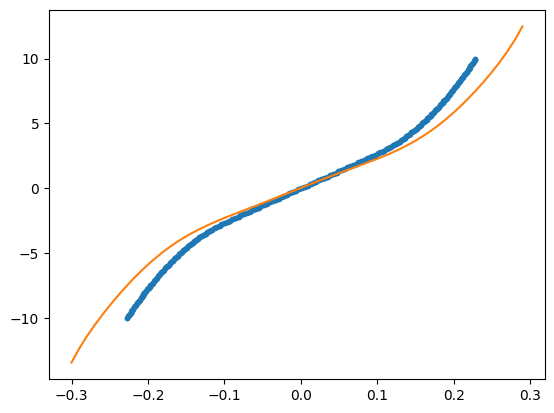

In [30]:
fields = np.arange(-0.3, 0.3, 0.01)
plt.plot(-measured['Xfield'], measured['V'],'.')
plt.plot(fields, base_volt_calib(fields))

### Fit new Calibration

[ 3.60445096e+06 -2.82207772e+04 -5.66523229e+05  3.38334651e+03
  3.24329479e+04 -1.34706253e+02 -3.42242966e+02  8.90926009e-01
  2.73199426e+01 -2.10792775e-02]


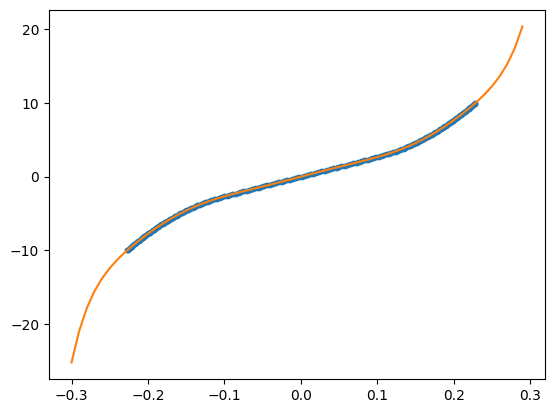

In [31]:
base_volt_coeff_new = np.polyfit(-measured['Xfield'], measured['V'], 9)
base_volt_calib_new = np.poly1d(base_volt_coeff_new)
print(base_volt_coeff_new)
plt.plot(-measured['Xfield'], measured['V'], '.')
fields = np.arange(-0.3, 0.3, 0.01)
plt.plot(fields, base_volt_calib_new(fields))
#save to volt_center (base_volt)

### Compare with old calibration

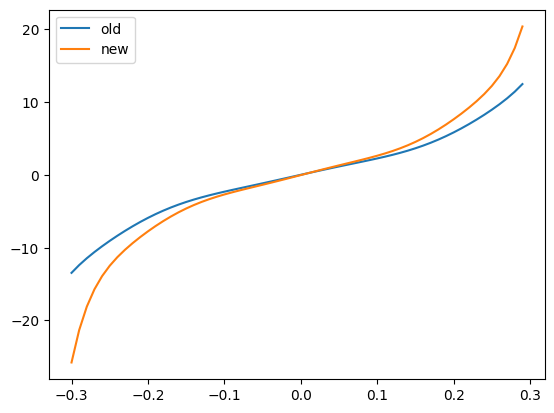

In [16]:
plt.plot(fields, base_volt_calib(fields), label = 'old')
plt.plot(fields, base_volt_calib_new(fields), label = 'new')
plt.legend()

### Check with 90deg

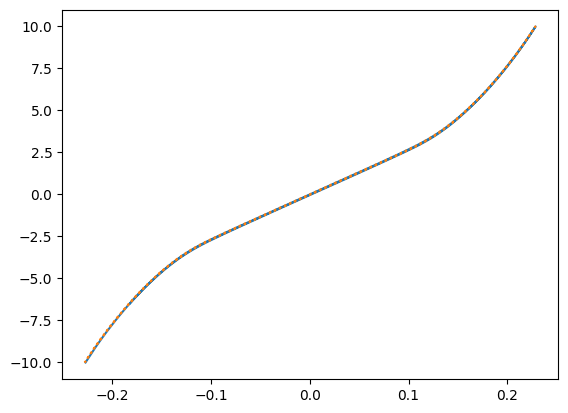

In [24]:
measured90deg = pd.read_csv(r"..\2026MayCal\voltCenter\2026-05-07\test3_daedalus_voltCenter_calib_2026-05-07_2.csv", comment = '#')
plt.plot(-measured['Xfield'], measured['V'])
plt.plot(-measured90deg['Zfield'], measured90deg['V'],linestyle='dotted')